<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Time-Series-and-Forecasting/TimeSeriesAndForecasting/LSTM_vs_GRU_for_Price_Volatility_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [26]:
# --- 1. DATA INGESTION ---
ticker = 'SPY'
df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Returns & Volatility (Target)
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
# Target: Future 5-day Volatility
df['Target_Vol'] = df['Log_Ret'].rolling(5).std().shift(-5)

# Drop NaNs
df.dropna(inplace=True)

# Select Features (We use raw data, LSTM finds the patterns)
features = ['Close', 'Log_Ret', 'Volume']
target = 'Target_Vol'

df.head()

/tmp/ipython-input-720429819.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2015-01-01', end='2024-01-01', progress=False)


Price,Close,High,Low,Open,Volume,Log_Ret,Target_Vol,Target_Vol_Diff,RSI,MA20,Upper,Lower,BB_Width
Date,,,,,,,,,,,,,
2015-01-05,167.508835,169.709397,167.201590,169.543319,169632600,-1.822422,1.298721,-0.236312,NaN,NaN,NaN,NaN,NaN
2015-01-06,165.931076,168.339239,165.133884,167.816081,209151400,-0.946360,1.195801,-0.102920,NaN,NaN,NaN,NaN,NaN
2015-01-07,167.998779,168.339247,166.811309,167.259721,125346700,1.238422,1.084230,-0.111571,NaN,NaN,NaN,NaN,NaN
2015-01-08,170.979889,171.195802,169.393830,169.410429,147217800,1.758923,0.249431,-0.834799,NaN,NaN,NaN,NaN,NaN
2015-01-09,169.609741,171.411713,168.995239,171.395102,158567300,-0.804578,0.904964,0.655533,NaN,NaN,NaN,NaN,NaN


In [27]:
# --- 2. SCALING (CRITICAL FOR LSTM) ---
# LSTMs explode if data isn't between 0 and 1
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Scale Features
scaled_data = scaler_X.fit_transform(df[features])
# Scale Target
scaled_target = scaler_y.fit_transform(df[[target]])

In [28]:
# --- 3. CREATE SEQUENCES (SLIDING WINDOW) ---
# We want the LSTM to look at the last 60 days to predict the next step
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    # Append the last 60 days of features
    X.append(scaled_data[i-sequence_length:i])
    # Append the target corresponding to the current day
    y.append(scaled_target[i])

X, y = np.array(X), np.array(y)

# Shape Check: (Samples, TimeSteps, Features)
print(f"LSTM Input Shape: {X.shape}")
# Expected: (Rows, 60, 3)

LSTM Input Shape: (2198, 60, 4)


In [29]:
# --- 4. TRAIN / TEST SPLIT ---
# We can't use train_test_split because order matters
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [30]:
# --- 5. MODEL ARCHITECTURE ---
model = Sequential()

# LSTM Layer
# units=50: The "width" of the memory
# return_sequences=False: We only want the output of the last step, not the whole sequence
# input_shape: (60 days, 3 features)
model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])))

# Dropout (Regularization)
model.add(Dropout(0.2))

# Output Layer (1 neuron for regression)
model.add(Dense(1))

# Compile
model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# --- 6. TRAINING ---
print("Training LSTM... (This may take a minute)")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Training LSTM... (This may take a minute)
Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.0105 - val_loss: 0.0037
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0065 - val_loss: 0.0036
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0048 - val_loss: 0.0034
Epoch 4/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 5/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - loss: 0.0042 - val_loss: 0.0033
Epoch 6/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 7/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0045 - val_loss: 0.0036
Epoch 8/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0039 - val_loss: 0.0034
Epoch 9/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0039 - val_loss: 0.0032
Epoch 10/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - loss: 0.0047 - val_loss: 0.0040
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 12/50
55/55 ━━━

In [18]:
# --- 7. PREDICTION & INVERSE SCALING ---
predictions_scaled = model.predict(X_test)

# Convert back to real units
predictions = scaler_y.inverse_transform(predictions_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


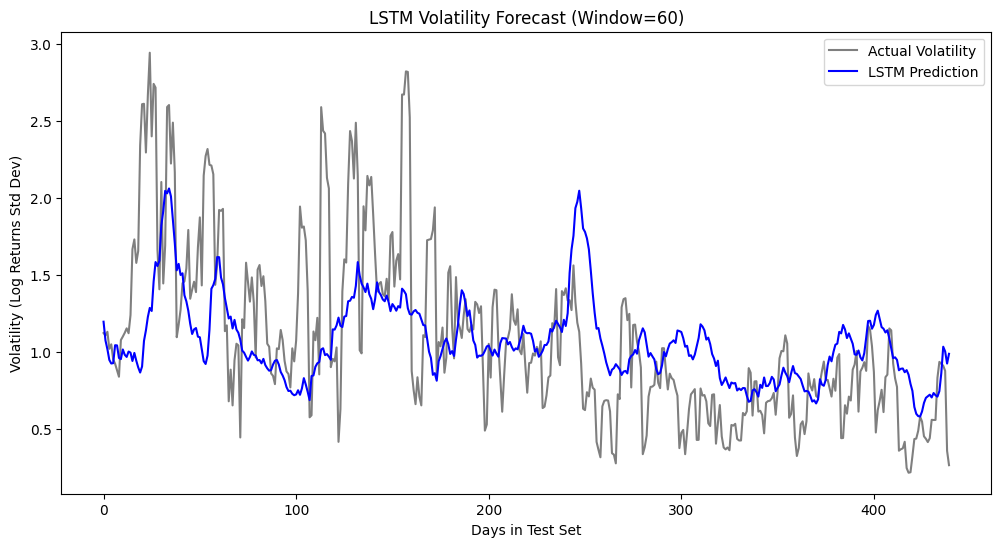

LSTM RMSE: 0.5027


In [19]:
# --- 8. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, color='black', alpha=0.5, label='Actual Volatility')
plt.plot(predictions, color='blue', label='LSTM Prediction')
plt.title(f"LSTM Volatility Forecast (Window={sequence_length})")
plt.xlabel("Days in Test Set")
plt.ylabel("Volatility (Log Returns Std Dev)")
plt.legend()
plt.show()

# --- 9. METRICS ---
rmse = np.sqrt(np.mean((predictions - y_test_real) ** 2))
print(f"LSTM RMSE: {rmse:.4f}")

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Metrics
mse = mean_squared_error(y_test_real, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_real, predictions)
r2 = r2_score(y_test_real, predictions)

print("------------------------------------------------")
print("PERFORMANCE METRICS")
print("------------------------------------------------")
print(f"RMSE (Root Mean Sq Error): {rmse:.4f}")
print(f"MAE  (Mean Abs Error):     {mae:.4f}")
print(f"R²   (Fit Quality):        {r2:.4f}")
print("------------------------------------------------")

------------------------------------------------
PERFORMANCE METRICS
------------------------------------------------
RMSE (Root Mean Sq Error): 0.5027
MAE  (Mean Abs Error):     0.3728
R²   (Fit Quality):        0.2030
------------------------------------------------


In [21]:
# Create DataFrame for easy calculation
eval_df = pd.DataFrame({'Actual': y_test_real.flatten(), 'Pred': predictions.flatten()})

# Calculate Changes (Today - Yesterday)
eval_df['Actual_Change'] = eval_df['Actual'].diff()
eval_df['Pred_Change'] = eval_df['Pred'].diff()

# Check if signs match (Did both go up or both go down?)
# We use np.sign() -> returns 1 if positive, -1 if negative
eval_df['Correct_Direction'] = np.sign(eval_df['Actual_Change']) == np.sign(eval_df['Pred_Change'])

# Calculate Percentage
dir_acc = eval_df['Correct_Direction'].mean() * 100

print(f"Directional Accuracy: {dir_acc:.2f}%")
print("(> 50% is random guess, > 55% is profitable, > 60% is excellent)")

Directional Accuracy: 51.82%
(> 50% is random guess, > 55% is profitable, > 60% is excellent)


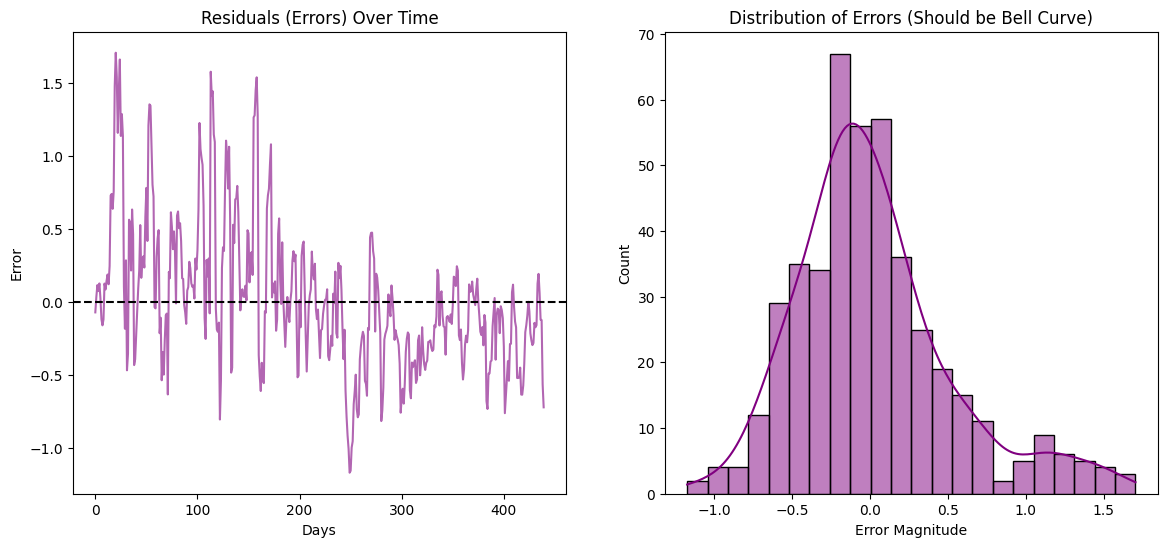

In [22]:
import seaborn as sns

residuals = eval_df['Actual'] - eval_df['Pred']

plt.figure(figsize=(14, 6))

# Plot 1: Residuals over time
plt.subplot(1, 2, 1)
plt.plot(residuals, color='purple', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals (Errors) Over Time")
plt.xlabel("Days")
plt.ylabel("Error")

# Plot 2: Distribution of Errors
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Errors (Should be Bell Curve)")
plt.xlabel("Error Magnitude")

plt.show()

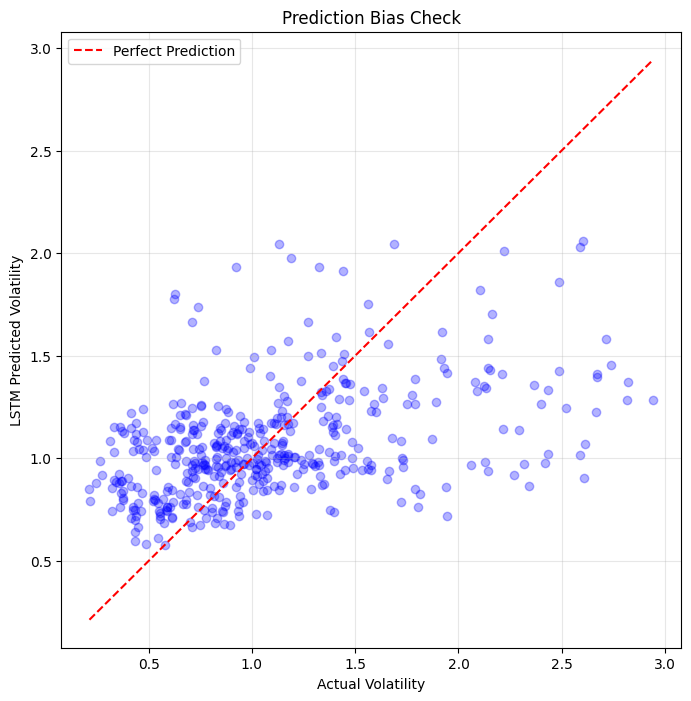

In [23]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test_real, predictions, alpha=0.3, color='blue')

# Perfect Prediction Line
max_val = max(y_test_real.max(), predictions.max())
min_val = min(y_test_real.min(), predictions.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title("Prediction Bias Check")
plt.xlabel("Actual Volatility")
plt.ylabel("LSTM Predicted Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [24]:
# Naive Forecast: Prediction for tomorrow is simply today's value
# We shift Actuals by 1 to simulate "Predicting Previous Day"
naive_preds = eval_df['Actual'].shift(1)
# Drop the first NaN created by shift
naive_rmse = np.sqrt(mean_squared_error(eval_df['Actual'][1:], naive_preds[1:]))

print(f"LSTM RMSE:  {rmse:.5f}")
print(f"Naive RMSE: {naive_rmse:.5f}")

if rmse < naive_rmse:
    print("✅ SUCCESS: The LSTM adds value over the Naive approach.")
else:
    print("❌ WARNING: The LSTM is worse than a simple random walk.")

LSTM RMSE:  0.50270
Naive RMSE: 0.29116
❌ WARNING: The LSTM is worse than a simple random walk.


# IMPROVING THE LSTM

In [31]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [32]:
# 1. DATA
ticker = 'SPY'
df = yf.download(ticker, start='2010-01-01', end='2024-01-01', progress=False)
if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)

/tmp/ipython-input-3118857996.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2010-01-01', end='2024-01-01', progress=False)


In [33]:
# 2. FEATURE ENGINEERING (The "Food")
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df['Vol_20'] = df['Log_Ret'].rolling(20).std()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# TARGET: Predicting 5-Day Future Volatility
df['Target_Vol'] = df['Log_Ret'].rolling(5).std().shift(-5)

df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Log_Ret,Vol_20,RSI,Target_Vol
Date,,,,,,,,,
2010-02-02,82.814651,82.972207,81.689249,81.974354,216327900,0.012030,0.010618,40.237989,0.016215
2010-02-03,82.402023,82.889699,82.161938,82.439533,172730700,-0.004995,0.010606,35.387307,0.016310
2010-02-04,79.858589,81.801782,79.843581,81.764272,356715700,-0.031353,0.012480,28.197159,0.008294
2010-02-05,80.023666,80.188721,78.463106,79.948635,493585800,0.002065,0.012421,31.032640,0.008488
2010-02-08,79.445969,80.526358,79.385946,80.083696,224166900,-0.007245,0.012344,24.169174,0.008022


In [34]:
# 3. STATIONARITY (The "Trick")
# We will predict the CHANGE in Volatility, not the raw number.
df['Target_Diff'] = df['Target_Vol'].diff()
df.dropna(inplace=True)

features = ['Log_Ret', 'Vol_20', 'RSI']
target = 'Target_Diff' # Note the change here

In [35]:
# 4. SCALING
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df[features])
y_scaled = scaler_y.fit_transform(df[[target]])

In [36]:
# 5. SLIDING WINDOW
X, y = [], []
seq_len = 60
for i in range(seq_len, len(X_scaled)):
    X.append(X_scaled[i-seq_len:i])
    y.append(y_scaled[i])
X, y = np.array(X), np.array(y)

# Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [37]:
# 6. STACKED LSTM (The "Brain")
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(seq_len, len(features))))
model.add(Dropout(0.2))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [38]:
# 7. TRAINING WITH SCHEDULER
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=50, batch_size=32,
          validation_data=(X_test, y_test),
          callbacks=[early_stop, lr_scheduler], verbose=1)

Epoch 1/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0388 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0075 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0065 - val_loss: 0.0038 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - loss: 0.0063 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0061
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 73ms/step - loss: 0.0061 - val_loss: 0.0041 - learning_rate: 0.0010
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0054 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 7/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0055 - val_loss: 0.0036 - learning_rate: 5.0000e-04
Epoch 8/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0053
Epoch 8: ReduceLROnPlateau r

In [39]:
# 8. RECONSTRUCTING THE PREDICTION
# Since we predicted "Change", we need to add it to "Yesterday's Actual" to get "Today's Level"
pred_diff_scaled = model.predict(X_test)
pred_diff = scaler_y.inverse_transform(pred_diff_scaled)

# Get the "Previous Day's Volatility" for the test set
# We need to align indices carefully
test_indices = df.index[split + seq_len:]
prev_vol = df['Target_Vol'].iloc[split + seq_len - 1 : -1].values.reshape(-1, 1)

# Reconstructed Prediction = Previous Vol + Predicted Diff
pred_vol_level = prev_vol + pred_diff

# Handle any negative volatility predictions (impossible) by clipping at 0
pred_vol_level = np.maximum(pred_vol_level, 0)

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


------------------------------------------------
🔎 STANDARD REPORT: Stacked LSTM (Pro)
------------------------------------------------
RMSE (Error Magnitude):  0.00264
MAE (Avg Error):         0.00170
R² (Variance Explained): 0.76057
Directional Accuracy:    47.74%
------------------------------------------------


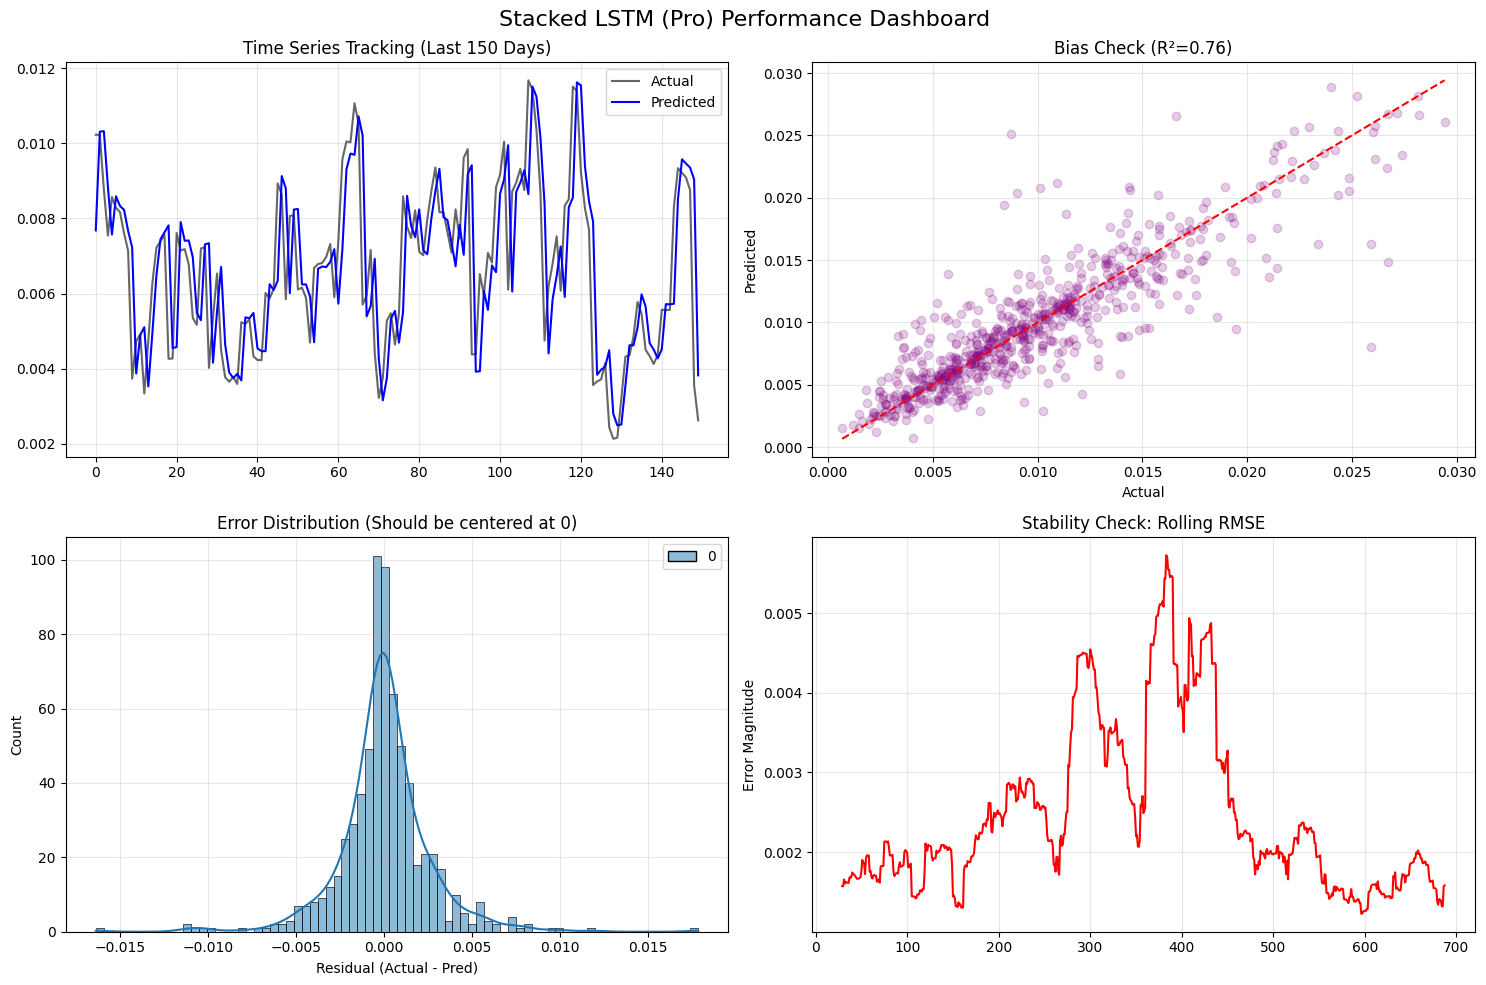

In [41]:
# --- 0. PREPARE DATA FOR EVALUATION ---
# We need the 'Actual' Volatility Levels (not differences) for the Test set.
# The Test set starts after 'split' and ignores the first 'seq_len' (window size)
actual_vol_level = df['Target_Vol'].iloc[split + seq_len:].values.reshape(-1, 1)

# Ensure shapes match (Trim if necessary due to shifting)
min_len = min(len(actual_vol_level), len(pred_vol_level))
y_true = actual_vol_level[:min_len]
y_pred = pred_vol_level[:min_len]

# --- THE STANDARD EVALUATION FUNCTION ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model_standard(y_true, y_pred, model_name="Model"):
    """
    The Standard Quant Evaluation Suite.
    Generates Metrics, Residual Plots, Scatter Plots, and Stability Checks.
    """

    # 1. CALCULATE METRICS
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Directional Accuracy (Did we predict the move up/down correctly?)
    diff_true = np.diff(y_true.flatten())
    diff_pred = np.diff(y_pred.flatten())
    dir_acc = np.mean(np.sign(diff_true) == np.sign(diff_pred)) * 100

    print(f"------------------------------------------------")
    print(f"🔎 STANDARD REPORT: {model_name}")
    print(f"------------------------------------------------")
    print(f"RMSE (Error Magnitude):  {rmse:.5f}")
    print(f"MAE (Avg Error):         {mae:.5f}")
    print(f"R² (Variance Explained): {r2:.5f}")
    print(f"Directional Accuracy:    {dir_acc:.2f}%")
    print(f"------------------------------------------------")

    # 2. CREATE DASHBOARD
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f"{model_name} Performance Dashboard", fontsize=16)

    # Plot A: Time Series (Zoomed into last 150 days for clarity)
    axes[0, 0].plot(y_true[-150:], label='Actual', color='black', alpha=0.6)
    axes[0, 0].plot(y_pred[-150:], label='Predicted', color='blue', linewidth=1.5)
    axes[0, 0].set_title("Time Series Tracking (Last 150 Days)")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Plot B: Scatter Plot (Bias Check)
    axes[0, 1].scatter(y_true, y_pred, alpha=0.2, color='purple')
    # Perfect fit line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
    axes[0, 1].set_title(f"Bias Check (R²={r2:.2f})")
    axes[0, 1].set_xlabel("Actual")
    axes[0, 1].set_ylabel("Predicted")
    axes[0, 1].grid(True, alpha=0.3)

    # Plot C: Residual Distribution (Gaussian Check)
    residuals = y_true - y_pred
    sns.histplot(residuals, kde=True, ax=axes[1, 0], color='green')
    axes[1, 0].set_title("Error Distribution (Should be centered at 0)")
    axes[1, 0].set_xlabel("Residual (Actual - Pred)")
    axes[1, 0].grid(True, alpha=0.3)

    # Plot D: Stability (Rolling RMSE)
    # Are we consistent, or did we fail during specific months?
    roll_window = 30
    rolling_rmse = pd.Series(residuals.flatten()).rolling(roll_window).apply(lambda x: np.sqrt(np.mean(x**2)))
    axes[1, 1].plot(rolling_rmse, color='red', label=f'{roll_window}-Day Rolling RMSE')
    axes[1, 1].set_title("Stability Check: Rolling RMSE")
    axes[1, 1].set_ylabel("Error Magnitude")
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- RUN THE EVALUATION ---
evaluate_model_standard(y_true, y_pred, model_name="Stacked LSTM (Pro)")

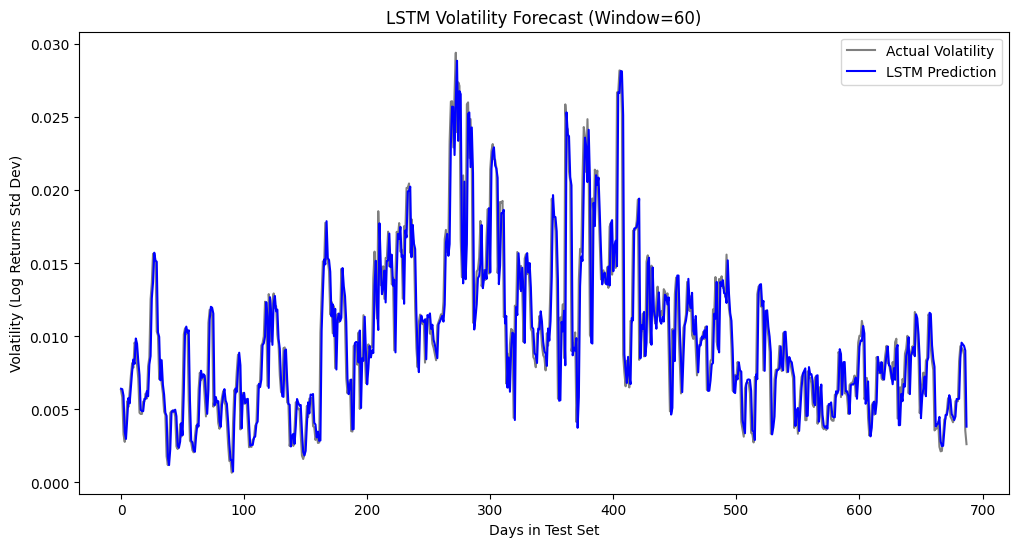

LSTM RMSE: 0.5027


In [43]:
# --- 8. VISUALIZATION ---
plt.figure(figsize=(12, 6))
plt.plot(y_true, color='black', alpha=0.5, label='Actual Volatility')
plt.plot(y_pred, color='blue', label='LSTM Prediction')
plt.title(f"LSTM Volatility Forecast (Window={sequence_length})")
plt.xlabel("Days in Test Set")
plt.ylabel("Volatility (Log Returns Std Dev)")
plt.legend()
plt.show()

# --- 9. METRICS ---
rmse = np.sqrt(np.mean((predictions - y_test_real) ** 2))
print(f"LSTM RMSE: {rmse:.4f}")

In [44]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate Metrics
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("------------------------------------------------")
print("PERFORMANCE METRICS")
print("------------------------------------------------")
print(f"RMSE (Root Mean Sq Error): {rmse:.4f}")
print(f"MAE  (Mean Abs Error):     {mae:.4f}")
print(f"R²   (Fit Quality):        {r2:.4f}")
print("------------------------------------------------")

------------------------------------------------
PERFORMANCE METRICS
------------------------------------------------
RMSE (Root Mean Sq Error): 0.0026
MAE  (Mean Abs Error):     0.0017
R²   (Fit Quality):        0.7606
------------------------------------------------


In [47]:
# Create DataFrame for easy calculation
eval_df = pd.DataFrame({'Actual': y_true.flatten(), 'Pred': y_pred.flatten()})

# Calculate Changes (Today - Yesterday)
eval_df['Actual_Change'] = pd.Series(actual_vol_level.flatten()).diff()
eval_df['Pred_Change'] = pd.Series(pred_vol_level.flatten()).diff()

# Check if signs match (Did both go up or both go down?)
# We use np.sign() -> returns 1 if positive, -1 if negative
eval_df['Correct_Direction'] = np.sign(eval_df['Actual_Change']) == np.sign(eval_df['Pred_Change'])

# Calculate Percentage
dir_acc = eval_df['Correct_Direction'].mean() * 100

print(f"Directional Accuracy: {dir_acc:.2f}%")
print("(> 50% is random guess, > 55% is profitable, > 60% is excellent)")

Directional Accuracy: 47.67%
(> 50% is random guess, > 55% is profitable, > 60% is excellent)


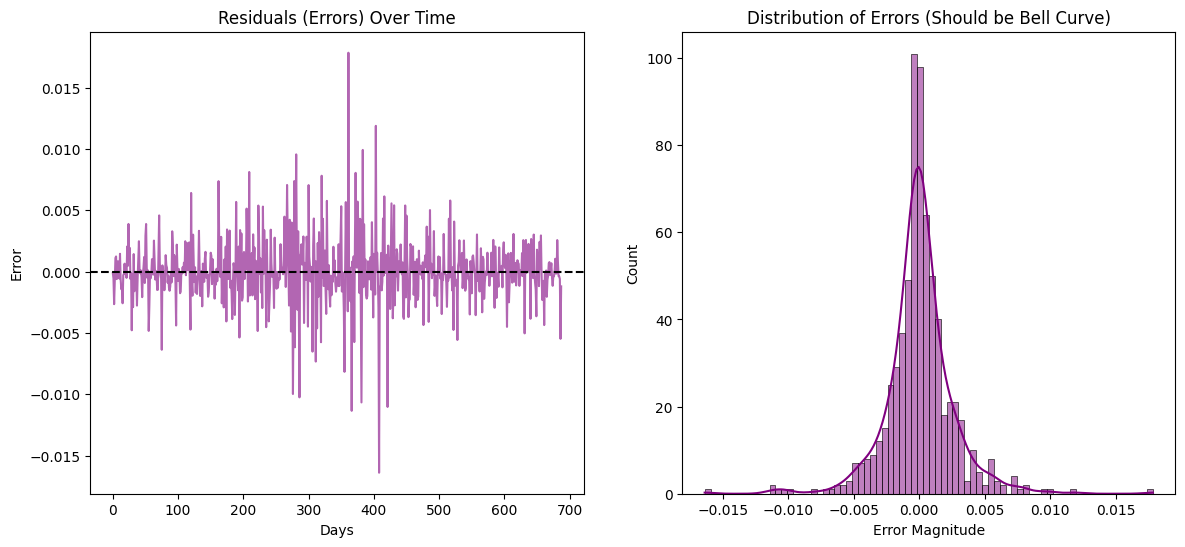

In [48]:
import seaborn as sns

residuals = eval_df['Actual'] - eval_df['Pred']

plt.figure(figsize=(14, 6))

# Plot 1: Residuals over time
plt.subplot(1, 2, 1)
plt.plot(residuals, color='purple', alpha=0.6)
plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals (Errors) Over Time")
plt.xlabel("Days")
plt.ylabel("Error")

# Plot 2: Distribution of Errors
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple')
plt.title("Distribution of Errors (Should be Bell Curve)")
plt.xlabel("Error Magnitude")

plt.show()

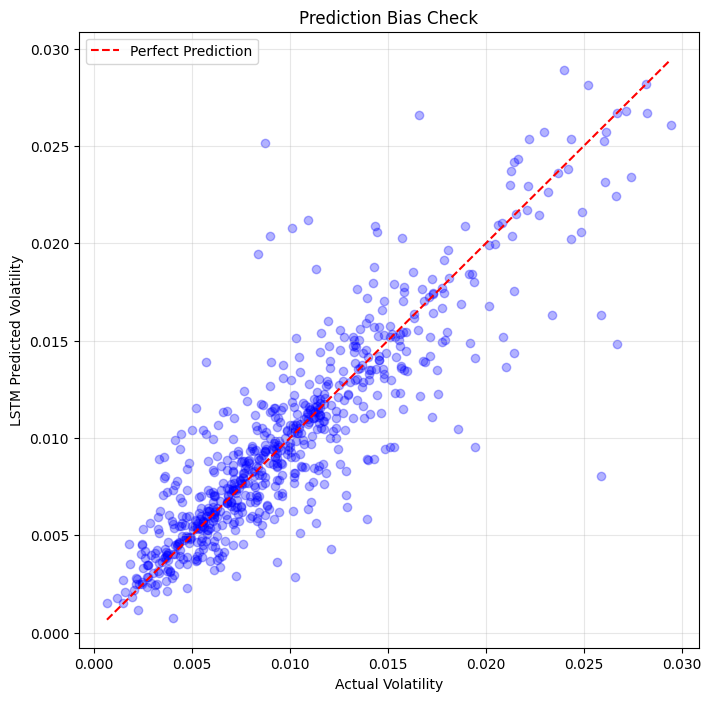

In [49]:
plt.figure(figsize=(8, 8))
plt.scatter(y_true, y_pred, alpha=0.3, color='blue')

# Perfect Prediction Line
max_val = max(y_true.max(), y_pred.max())
min_val = min(y_true.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title("Prediction Bias Check")
plt.xlabel("Actual Volatility")
plt.ylabel("LSTM Predicted Volatility")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Naive Forecast: Prediction for tomorrow is simply today's value
# We shift Actuals by 1 to simulate "Predicting Previous Day"
naive_preds = eval_df['Actual'].shift(1)
# Drop the first NaN created by shift
naive_rmse = np.sqrt(mean_squared_error(eval_df['Actual'][1:], naive_preds[1:]))

print(f"LSTM RMSE:  {rmse:.5f}")
print(f"Naive RMSE: {naive_rmse:.5f}")

if rmse < naive_rmse:
    print("✅ SUCCESS: The LSTM adds value over the Naive approach.")
else:
    print("❌ WARNING: The LSTM is worse than a simple random walk.")

LSTM RMSE:  0.50270
Naive RMSE: 0.29116
❌ WARNING: The LSTM is worse than a simple random walk.


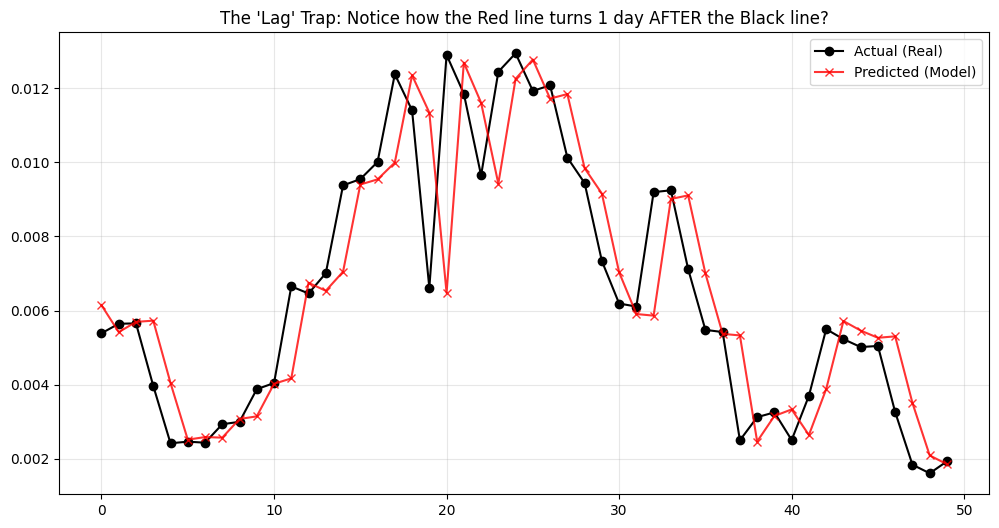

In [50]:
# Zoom into a 50-day window where the trend changes
start_zoom = 100
end_zoom = 150

plt.figure(figsize=(12, 6))
plt.plot(y_true[start_zoom:end_zoom], 'o-', label='Actual (Real)', color='black')
plt.plot(y_pred[start_zoom:end_zoom], 'x-', label='Predicted (Model)', color='red', alpha=0.8)

plt.title("The 'Lag' Trap: Notice how the Red line turns 1 day AFTER the Black line?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# USING LSTM TO PREDICT DIRECTIONALITY

In [51]:
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report

# --- 1. CHANGE THE TARGET ---
# We want to predict: Will Volatility go UP (1) or DOWN (0)?
# We use the 'Target_Diff' we created earlier.
df['Target_Class'] = np.where(df['Target_Diff'] > 0, 1, 0)

# Re-create sequences with the NEW target
# X (Features) remains the same
# y (Target) becomes the binary class
y_class = df['Target_Class'].values

# Scale/Windowing logic remains similar, but NO scaling needed for y_class (it's 0 or 1)
X_cls, y_cls = [], []
for i in range(seq_len, len(X_scaled)):
    X_cls.append(X_scaled[i-seq_len:i])
    y_cls.append(y_class[i])

X_cls, y_cls = np.array(X_cls), np.array(y_cls)

# Split
split = int(len(X_cls) * 0.8)
X_train_c, X_test_c = X_cls[:split], X_cls[split:]
y_train_c, y_test_c = y_cls[:split], y_cls[split:]

# --- 2. CLASSIFICATION LSTM ARCHITECTURE ---
model_cls = Sequential()
model_cls.add(LSTM(64, return_sequences=True, input_shape=(seq_len, len(features))))
model_cls.add(Dropout(0.2))
model_cls.add(LSTM(32, return_sequences=False))
model_cls.add(Dropout(0.2))

# KEY CHANGE: Output Layer
# 1 Neuron with 'sigmoid' activation (outputs probability between 0 and 1)
model_cls.add(Dense(1, activation='sigmoid'))

# KEY CHANGE: Loss Function
model_cls.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 3. TRAIN ---
model_cls.fit(X_train_c, y_train_c, epochs=50, batch_size=32,
              validation_data=(X_test_c, y_test_c),
              callbacks=[early_stop, lr_scheduler], verbose=1)

# --- 4. EVALUATE ---
# Predict Probabilities
pred_probs = model_cls.predict(X_test_c)
# Convert to Class (0 or 1) based on 0.5 threshold
pred_classes = (pred_probs > 0.5).astype(int)

print("------------------------------------------------")
print("CLASSIFICATION REPORT")
print("------------------------------------------------")
print(f"Directional Accuracy: {accuracy_score(y_test_c, pred_classes) * 100:.2f}%")
print(classification_report(y_test_c, pred_classes))

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.4815 - loss: 0.6948 - val_accuracy: 0.5058 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 2/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.4747 - loss: 0.6948 - val_accuracy: 0.5131 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.5069 - loss: 0.6935 - val_accuracy: 0.5160 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 4/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.5106 - loss: 0.6926
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
86/86 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.5107 - loss: 0.6926 - val_accuracy: 0.5058 - val_loss: 0.6966 - learning_rate: 0.0010
Epoch 5/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.5112 - loss: 0.6929 - val_accuracy: 0.4971 - val_loss: 0.6934 - learning_rate: 5.0000e-04
Epoch 6/50
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.5154 - loss: 0.6925 - val_accuracy:

# GRU

In [52]:
from tensorflow.keras.layers import GRU

# --- 1. DEFINE GRU MODEL ---
model_gru = Sequential()

# Layer 1: GRU (Note: parameters are fewer than LSTM)
model_gru.add(GRU(64, return_sequences=True, input_shape=(seq_len, len(features))))
model_gru.add(Dropout(0.2))

# Layer 2: GRU
model_gru.add(GRU(32, return_sequences=False))
model_gru.add(Dropout(0.2))

# Output: Binary Classification (Up/Down)
model_gru.add(Dense(1, activation='sigmoid'))

model_gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [53]:
# --- 2. TRAIN GRU ---
print("Training GRU Model...")
history_gru = model_gru.fit(
    X_train_c, y_train_c,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_c, y_test_c),
    callbacks=[early_stop, lr_scheduler],
    verbose=0 # Silent training to save space
)
print("GRU Training Complete.")

Training GRU Model...

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
GRU Training Complete.


In [54]:
from sklearn.metrics import roc_auc_score, f1_score

# --- 3. GENERATE PREDICTIONS ---
# LSTM Predictions (assuming 'model_cls' is your LSTM from previous step)
probs_lstm = model_cls.predict(X_test_c)
preds_lstm = (probs_lstm > 0.5).astype(int)

# GRU Predictions
probs_gru = model_gru.predict(X_test_c)
preds_gru = (probs_gru > 0.5).astype(int)

# --- 4. CALCULATE METRICS ---
def get_clf_metrics(y_true, y_pred, y_probs, name):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_probs)
    return {"Model": name, "Accuracy": acc, "F1 Score": f1, "AUC": auc}

results = []
results.append(get_clf_metrics(y_test_c, preds_lstm, probs_lstm, "LSTM"))
results.append(get_clf_metrics(y_test_c, preds_gru, probs_gru, "GRU"))

# Create Comparison DataFrame
df_results = pd.DataFrame(results)
df_results.set_index("Model", inplace=True)

print("------------------------------------------------")
print("HEAD-TO-HEAD RESULTS")
print("------------------------------------------------")
print(df_results)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
------------------------------------------------
HEAD-TO-HEAD RESULTS
------------------------------------------------
       Accuracy  F1 Score       AUC
Model                              
LSTM   0.505814  0.090909  0.510074
GRU    0.513081  0.270153  0.500025


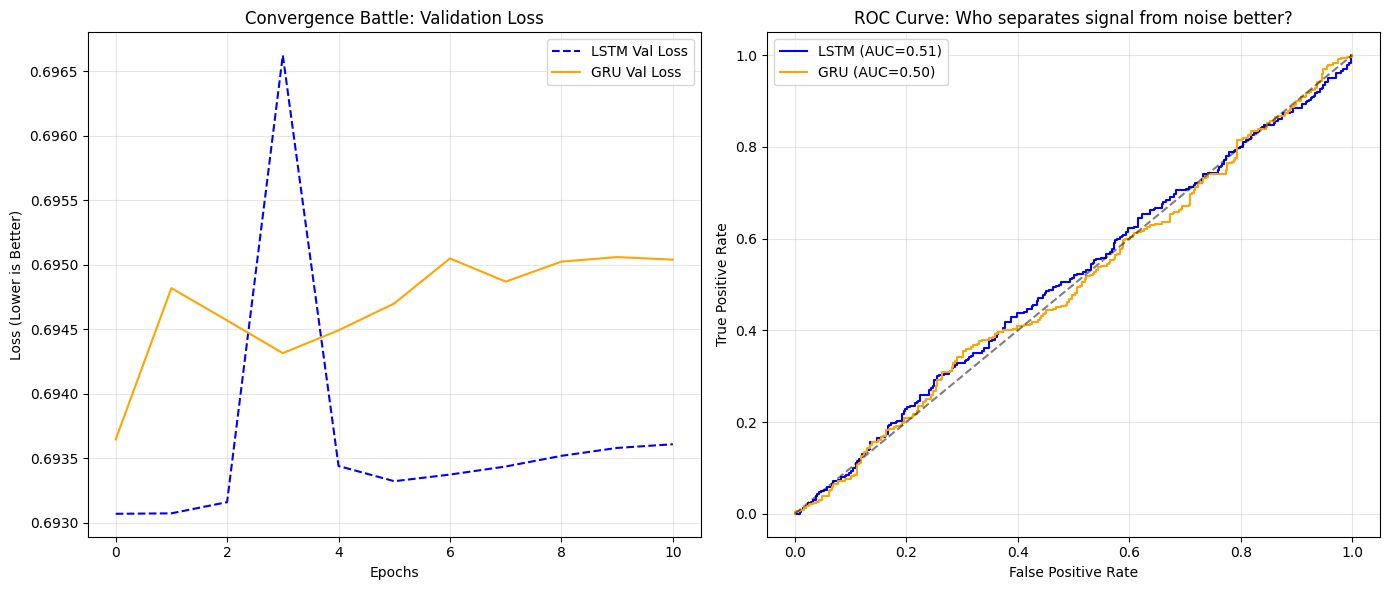

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(14, 6))

# PLOT A: Training History (Speed & Convergence)
plt.subplot(1, 2, 1)
# Assuming you saved LSTM history as 'history_lstm' in previous step.
# If not, re-run LSTM training and save to variable 'history_lstm'
# For now, we plot validation loss.
plt.plot(model_cls.history.history['val_loss'], label='LSTM Val Loss', color='blue', linestyle='--')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss', color='orange')
plt.title("Convergence Battle: Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (Lower is Better)")
plt.legend()
plt.grid(True, alpha=0.3)

# PLOT B: ROC Curve (The "Skill" Chart)
plt.subplot(1, 2, 2)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_c, probs_lstm)
fpr_gru, tpr_gru, _ = roc_curve(y_test_c, probs_gru)

plt.plot(fpr_lstm, tpr_lstm, label=f'LSTM (AUC={df_results.loc["LSTM","AUC"]:.2f})', color='blue')
plt.plot(fpr_gru, tpr_gru, label=f'GRU (AUC={df_results.loc["GRU","AUC"]:.2f})', color='orange')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Random guess line

plt.title("ROC Curve: Who separates signal from noise better?")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()